In [ ]:
import openslide
from openslide import OpenSlide
import matplotlib.pyplot as plt
import numpy as np

In [9]:
import os

os.chdir("/home/ubuntu/giodir/digitalPathology/")

In [10]:
# ── 1. Open the slide ──────────────────────────────────────────────────────────
slide = OpenSlide("data/share/OSR/OSR_1_E1_083951.svs")

In [11]:

# ── 2. Basic metadata ──────────────────────────────────────────────────────────
print("Format       :", slide.detect_format("path/to/your/file.svs"))
print("Level count  :", slide.level_count)
print("Dimensions   :", slide.dimensions)          # (width, height) at level 0
print("Level dims   :", slide.level_dimensions)    # list of (w, h) per level
print("Level downsamples:", slide.level_downsamples)
print("Properties   :")
for k, v in slide.properties.items():
    print(f"  {k}: {v}")

Format       : None
Level count  : 3
Dimensions   : (54247, 54247)
Level dims   : ((54247, 54247), (13561, 13561), (3390, 3390))
Level downsamples: (1.0, 4.000221222623701, 16.00206489675516)
Properties   :
  aperio.AppMag: 40
  aperio.CalibrationAverageBlue: 222.29414367676
  aperio.CalibrationAverageGreen: 222.89614868164
  aperio.CalibrationAverageRed: 221.4022064209
  aperio.Date: 09/24/2025
  aperio.Exposure Scale: 0.000001
  aperio.Exposure Time: 8
  aperio.Filtered: 3
  aperio.Focus Offset: 0.000000
  aperio.Gamma: 2.2
  aperio.Left: 17.79091835022
  aperio.MPP: 0.262613
  aperio.Rack: 2
  aperio.Scan Warning: NO_BARCODE;IQ_TILT
  aperio.ScanScope ID: SS45227
  aperio.ScannerType: GT450 DX
  aperio.SessionMode: PDX
  aperio.Slide: 6
  aperio.StripeWidth: 4096
  aperio.Time: 08:40:03
  aperio.Time Zone: GMT+0200
  aperio.Top: 34.153442382812
  openslide.comment: Aperio Leica Biosystems GT450 DX v1.2.2 
54247x54247 [0,0,54247x54247] (256x256) JPEG/YCC Q=91|AppMag = 40|CalibrationA

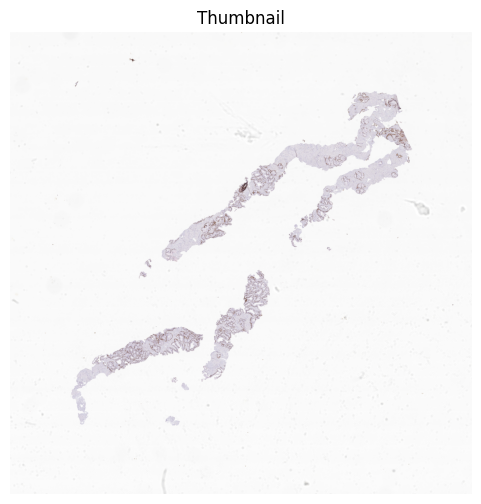

In [12]:
# ── 3. Read a thumbnail (fast overview) ───────────────────────────────────────
thumbnail = slide.get_thumbnail((1024, 1024))   # max size, keeps aspect ratio

plt.figure(figsize=(6, 6))
plt.imshow(thumbnail)
plt.title("Thumbnail")
plt.axis("off")
plt.show()

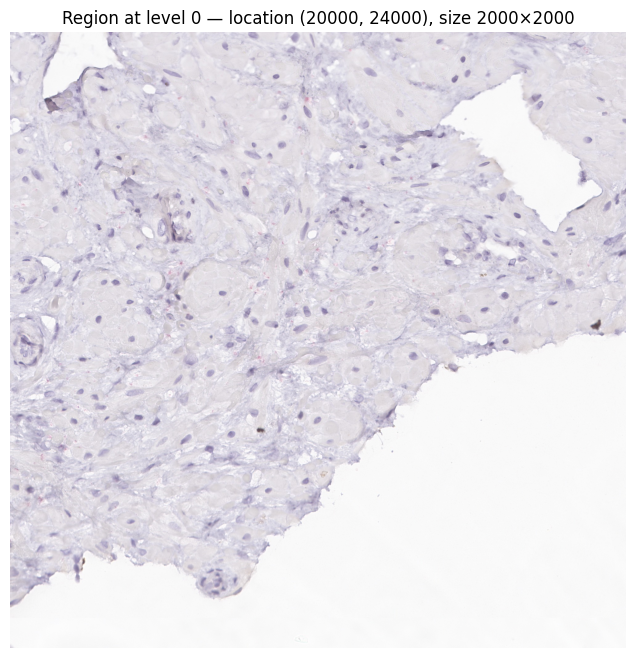

In [19]:
# ── 4. Read a specific region at a chosen resolution level ────────────────────
# Level 0 = full resolution (can be 100k x 80k px — never load fully!)
# Level 1, 2, ... = progressively downsampled

LEVEL = 0                      # pick a coarser level to stay light
x, y = 20000, 24000            # top-left corner in level-0 coordinates
width, height = 2000, 2000     # size of the region to extract (in level pixels)

region = slide.read_region(
    location=(x, y),           # always in level-0 pixel coords
    level=LEVEL,
    size=(width, height)
)

# read_region returns a PIL RGBA image → convert to RGB
region_rgb = region.convert("RGB")

plt.figure(figsize=(8, 8))
plt.imshow(region_rgb)
plt.title(f"Region at level {LEVEL} — location ({x}, {y}), size {width}×{height}")
plt.axis("off")
plt.show()